<a href="https://colab.research.google.com/github/DMariano0912/DeepLearningECGR4106/blob/main/DeepLearning_Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem 1:

Setup and Data:

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
from collections import Counter

#Text Loading
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

Pre-Processing:

In [16]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_ix = {ch:i for i,ch in enumerate(chars)}
ix_to_char = {i:ch for i,ch in enumerate(chars)}

def encode(s):
    return [char_to_ix[c] for c in s]

def decode(l):
    return ''.join(ix_to_char[i] for i in l)

def create_sequences(text, seq_len):
    data = encode(text)
    X, Y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        Y.append(data[i+seq_len])

    return np.array(X), np.array(Y)

Setting up Models:

In [17]:
class CharModel(nn.Module):
    def __init__(self, model_type, vocab_size, hidden_size=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_size)

        if model_type == "RNN":
            self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        elif model_type == "GRU":
            self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.model_type = model_type

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

Training Fucntions:

In [18]:
def train_model(model, X_train, Y_train, X_val, Y_val, epochs=10, lr=0.003):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        inputs = torch.tensor(X_train).to(device)
        targets = torch.tensor(Y_train).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        #Model Validation
        model.eval()
        with torch.no_grad():
            val_inputs = torch.tensor(X_val).to(device)
            val_targets = torch.tensor(Y_val).to(device)

            outputs = model(val_inputs)
            preds = torch.argmax(outputs, dim=1)
            acc = (preds == val_targets).float().mean().item()
            val_accuracies.append(acc)

        print(f"Epoch {epoch+1}: Loss={loss.item():.4f}, Val Acc={acc:.4f}")

    total_time = time.time() - start_time

    return train_losses, val_accuracies, total_time

Running the Models:

In [19]:
sequence_lengths = [10, 20, 30]
model_types = ["RNN", "LSTM", "GRU"]

results = {}

for seq_len in sequence_lengths:
    print(f"\n=== Sequence Length: {seq_len} ===")

    X, Y = create_sequences(text, seq_len)

    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    Y_train, Y_val = Y[:split], Y[split:]

    for model_type in model_types:
        print(f"\nTraining {model_type}...")

        model = CharModel(model_type, vocab_size)

        params = sum(p.numel() for p in model.parameters())

        train_losses, val_accs, train_time = train_model(
            model, X_train, Y_train, X_val, Y_val
        )

        results[(model_type, seq_len)] = {
            "loss": train_losses,
            "acc": val_accs,
            "time": train_time,
            "params": params
        }


=== Sequence Length: 10 ===

Training RNN...
Epoch 1: Loss=3.8530, Val Acc=0.1132
Epoch 2: Loss=3.5699, Val Acc=0.2013
Epoch 3: Loss=3.3012, Val Acc=0.2180
Epoch 4: Loss=3.0453, Val Acc=0.2117
Epoch 5: Loss=2.8526, Val Acc=0.2138
Epoch 6: Loss=2.7476, Val Acc=0.2243
Epoch 7: Loss=2.6655, Val Acc=0.2327
Epoch 8: Loss=2.5881, Val Acc=0.2474
Epoch 9: Loss=2.5185, Val Acc=0.2621
Epoch 10: Loss=2.4597, Val Acc=0.2830

Training LSTM...
Epoch 1: Loss=3.8080, Val Acc=0.1216
Epoch 2: Loss=3.6932, Val Acc=0.1929
Epoch 3: Loss=3.5665, Val Acc=0.1656
Epoch 4: Loss=3.4078, Val Acc=0.1551
Epoch 5: Loss=3.2137, Val Acc=0.1447
Epoch 6: Loss=3.0235, Val Acc=0.1342
Epoch 7: Loss=2.9112, Val Acc=0.1384
Epoch 8: Loss=2.8652, Val Acc=0.1782
Epoch 9: Loss=2.8183, Val Acc=0.2117
Epoch 10: Loss=2.7612, Val Acc=0.2243

Training GRU...
Epoch 1: Loss=3.8164, Val Acc=0.1426
Epoch 2: Loss=3.5978, Val Acc=0.1866
Epoch 3: Loss=3.3808, Val Acc=0.1803
Epoch 4: Loss=3.1618, Val Acc=0.1698
Epoch 5: Loss=2.9738, Val Acc

Graphing:

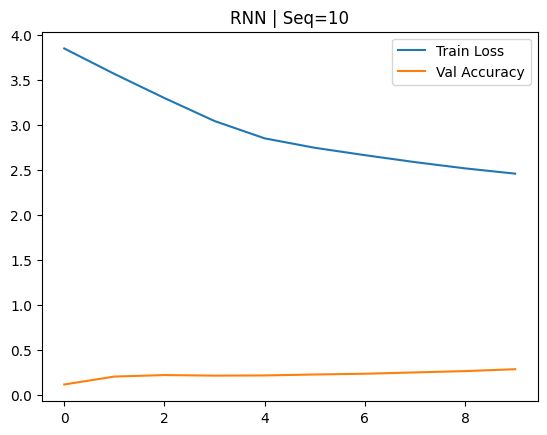

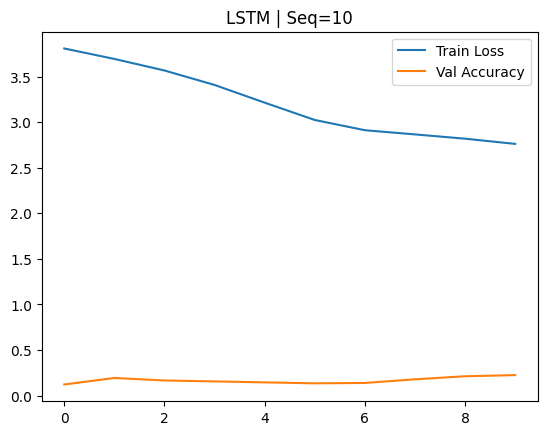

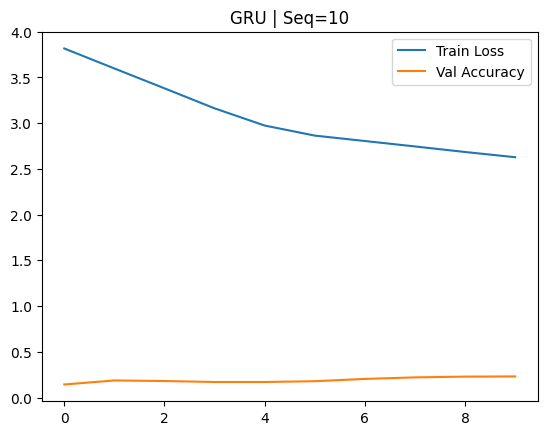

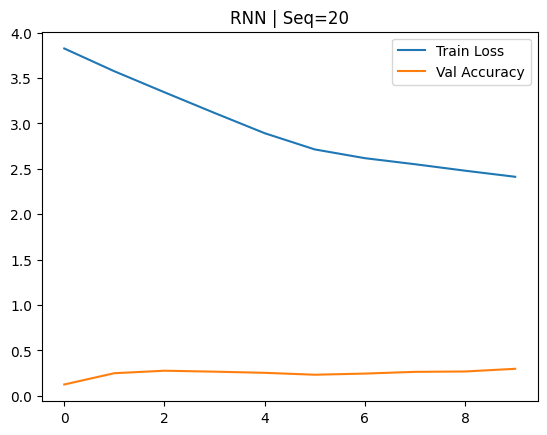

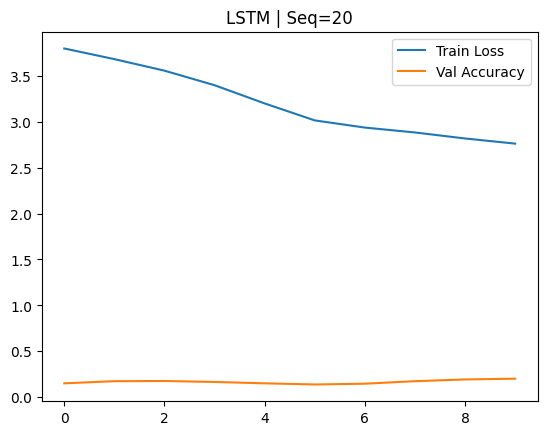

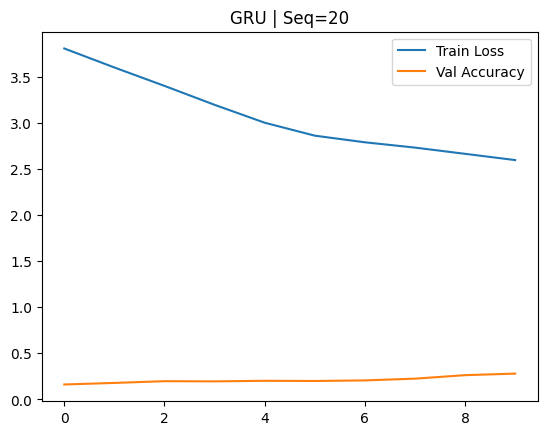

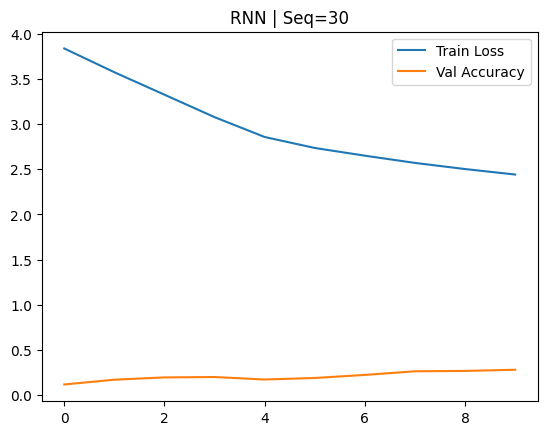

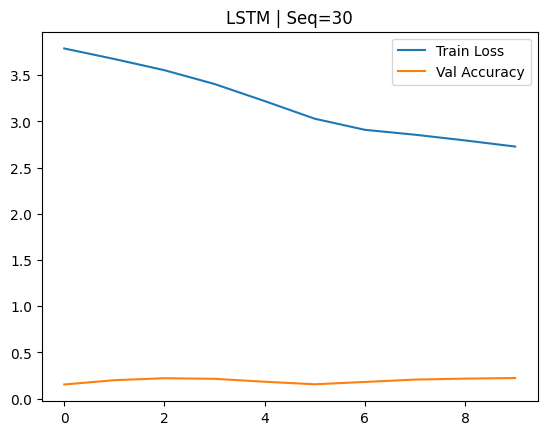

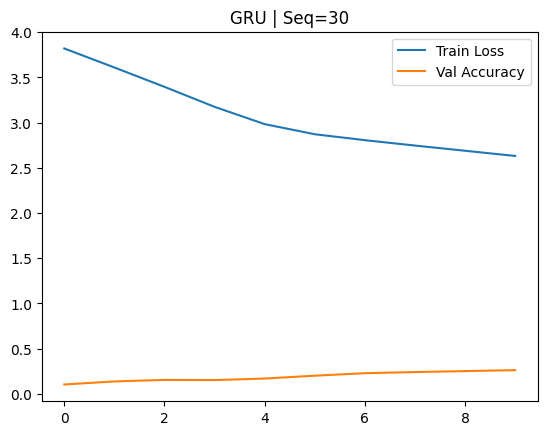

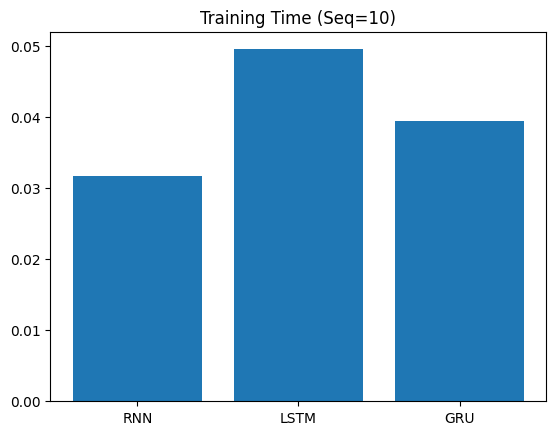

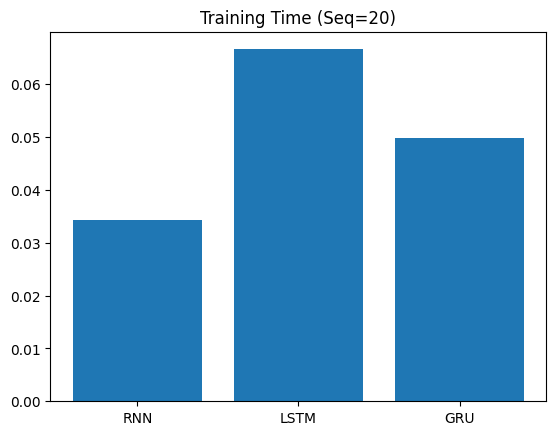

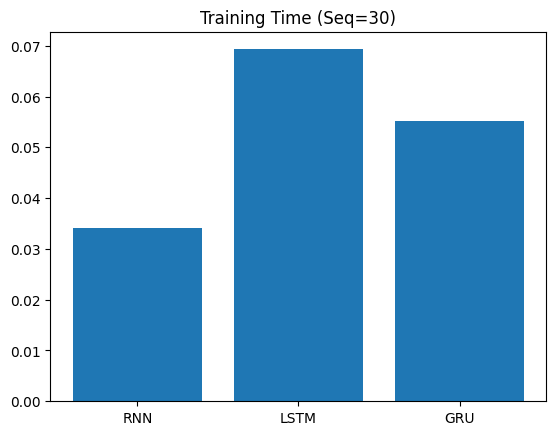

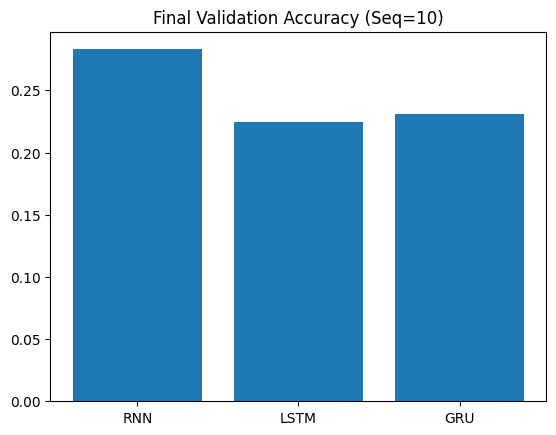

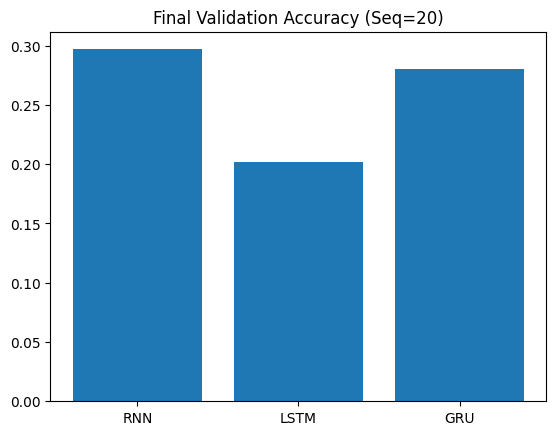

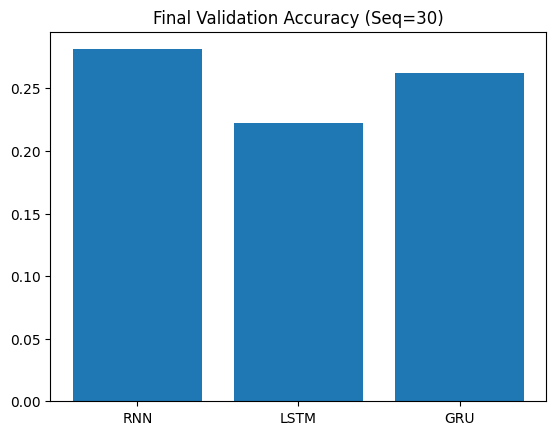

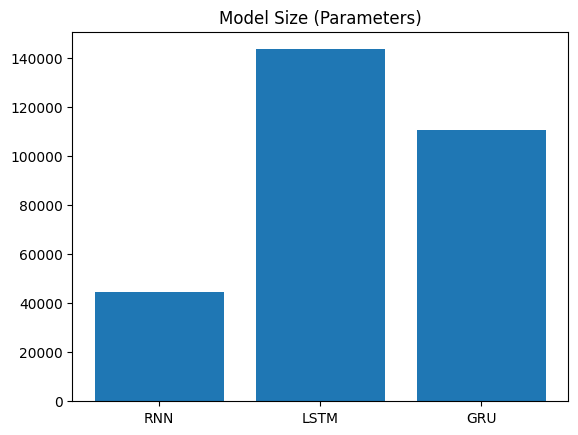

In [20]:
for (model_type, seq_len), res in results.items():
    plt.figure()
    plt.plot(res["loss"], label="Train Loss")
    plt.plot(res["acc"], label="Val Accuracy")
    plt.title(f"{model_type} | Seq={seq_len}")
    plt.legend()
    plt.show()

#Length of Training Time

for seq_len in sequence_lengths:
  times = [results[(m, seq_len)]["time"] for m in model_types]

  plt.figure()
  plt.bar(model_types, times)
  plt.title(f"Training Time (Seq={seq_len})")
  plt.show()

#Accuracies
for seq_len in sequence_lengths:
    accs = [results[(m, seq_len)]["acc"][-1] for m in model_types]

    plt.figure()
    plt.bar(model_types, accs)
    plt.title(f"Final Validation Accuracy (Seq={seq_len})")
    plt.show()

#Parameter Count
params = [results[(m, 10)]["params"] for m in model_types]

plt.figure()
plt.bar(model_types, params)
plt.title("Model Size (Parameters)")
plt.show()

##**Problem 2:**

Shakespeare Loader (Adjusted):

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import math
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text

print("Dataset length:", len(text))

def build_loaders(text, seq_length, batch_size=128):
    chars = sorted(list(set(text)))
    char_to_int = {ch: i for i, ch in enumerate(chars)}
    int_to_char = {i: ch for i, ch in enumerate(chars)}

    encoded = [char_to_int[ch] for ch in text]

    sequences, targets = [], []
    for i in range(len(encoded) - seq_length):
        sequences.append(encoded[i:i+seq_length])
        targets.append(encoded[i+seq_length])

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets = torch.tensor(targets, dtype=torch.long)

    dataset = torch.utils.data.TensorDataset(sequences, targets)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, test_loader, len(chars), char_to_int, int_to_char

Dataset length: 1115394


Defining Models:

In [22]:
class CharModel(nn.Module):
    def __init__(self, model_type, vocab_size, embed_size=128, hidden_size=128, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        if model_type == "LSTM":
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif model_type == "GRU":
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers=num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

Training:

In [23]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)

            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total


def train_model(model, train_loader, test_loader, epochs=5, lr=0.003):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses, val_accs = [], [], []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        train_loss = epoch_loss / len(train_loader)
        val_loss, val_acc = evaluate(model, test_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

    total_time = time.time() - start_time

    return train_losses, val_losses, val_accs, total_time

Run Models:

In [24]:
sequence_lengths = [20, 30, 50]
model_types = ["LSTM", "GRU"]

results = {}

for seq_len in sequence_lengths:
    print(f"\n===== Sequence Length: {seq_len} =====")

    train_loader, test_loader, vocab_size, char_to_int, int_to_char = build_loaders(text, seq_len)

    for model_type in model_types:
        print(f"\nTraining {model_type}...")

        model = CharModel(model_type, vocab_size, hidden_size=128, num_layers=1)

        param_count = sum(p.numel() for p in model.parameters())

        train_losses, val_losses, val_accs, train_time = train_model(
            model, train_loader, test_loader
        )

        results[(model_type, seq_len)] = {
            "train_loss": train_losses,
            "val_loss": val_losses,
            "val_acc": val_accs,
            "time": train_time,
            "params": param_count,
            "model": model,
            "char_to_int": char_to_int,
            "int_to_char": int_to_char
        }


===== Sequence Length: 20 =====

Training LSTM...
Epoch 1: Train Loss=1.7517, Val Acc=0.5143
Epoch 2: Train Loss=1.5594, Val Acc=0.5297
Epoch 3: Train Loss=1.5127, Val Acc=0.5388
Epoch 4: Train Loss=1.4890, Val Acc=0.5427
Epoch 5: Train Loss=1.4737, Val Acc=0.5465

Training GRU...
Epoch 1: Train Loss=1.7676, Val Acc=0.5032
Epoch 2: Train Loss=1.6314, Val Acc=0.5084
Epoch 3: Train Loss=1.6092, Val Acc=0.5106
Epoch 4: Train Loss=1.6064, Val Acc=0.5138
Epoch 5: Train Loss=1.6053, Val Acc=0.5164

===== Sequence Length: 30 =====

Training LSTM...
Epoch 1: Train Loss=1.7485, Val Acc=0.5187
Epoch 2: Train Loss=1.5583, Val Acc=0.5367
Epoch 3: Train Loss=1.5119, Val Acc=0.5400
Epoch 4: Train Loss=1.4882, Val Acc=0.5473
Epoch 5: Train Loss=1.4737, Val Acc=0.5475

Training GRU...
Epoch 1: Train Loss=1.7629, Val Acc=0.5059
Epoch 2: Train Loss=1.6250, Val Acc=0.5171
Epoch 3: Train Loss=1.6068, Val Acc=0.5187
Epoch 4: Train Loss=1.6056, Val Acc=0.5203
Epoch 5: Train Loss=1.6073, Val Acc=0.5168

===

Graphs and Comparison:

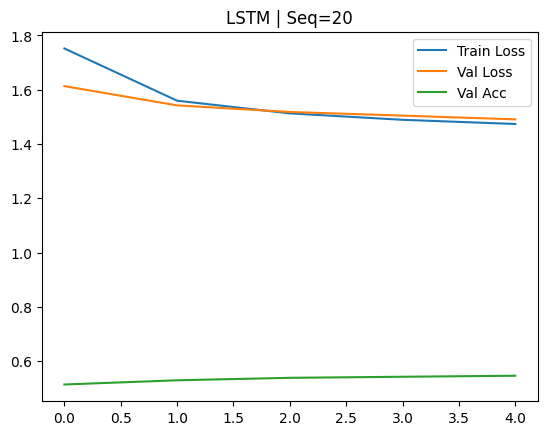

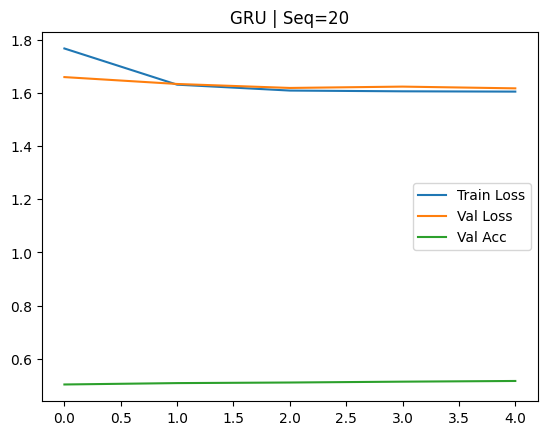

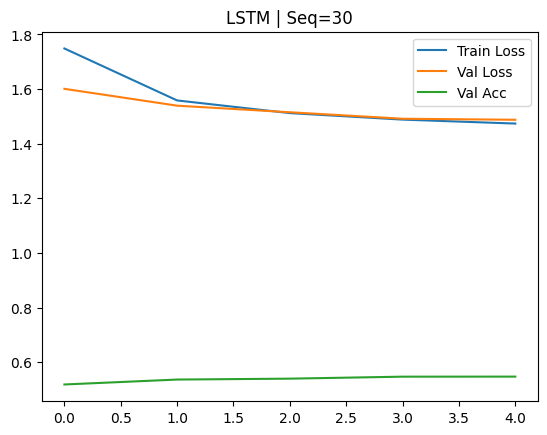

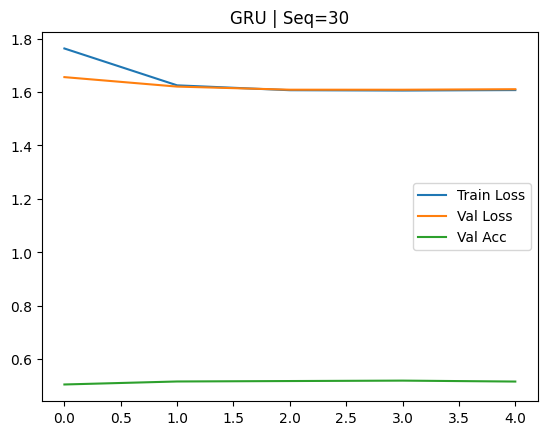

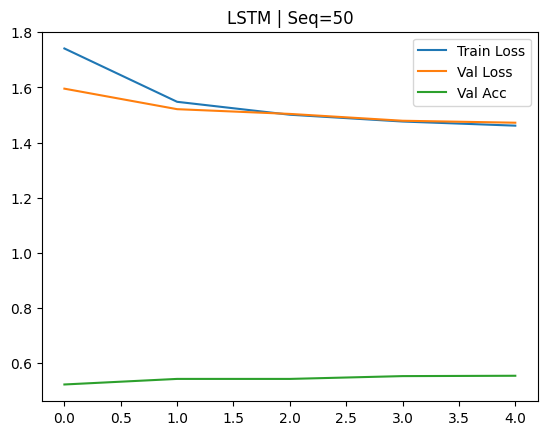

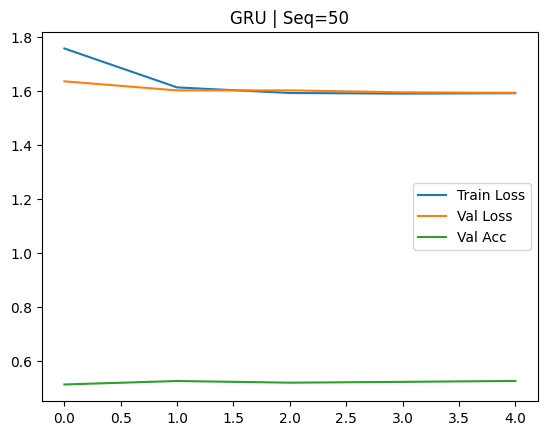

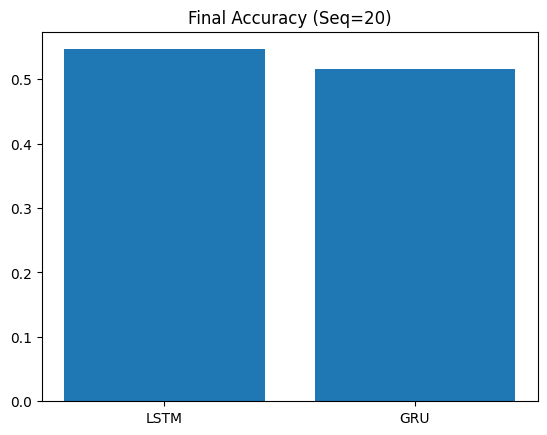

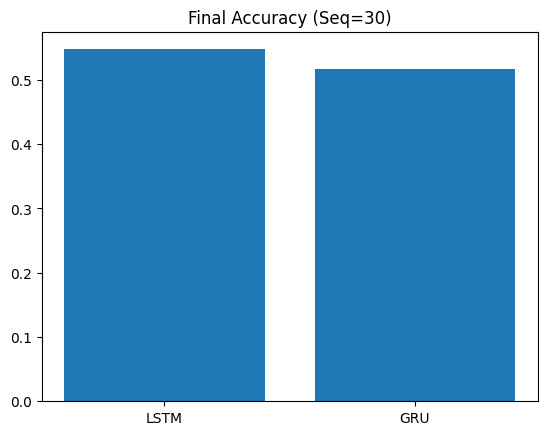

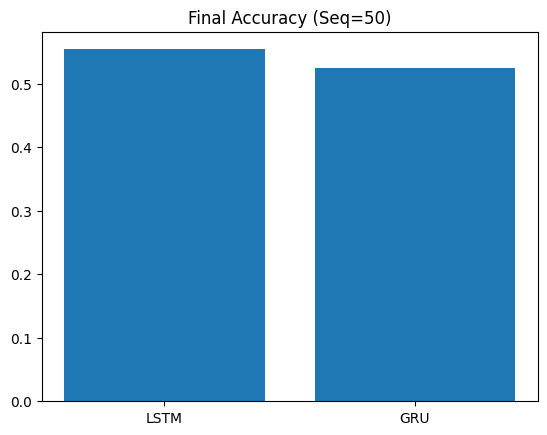

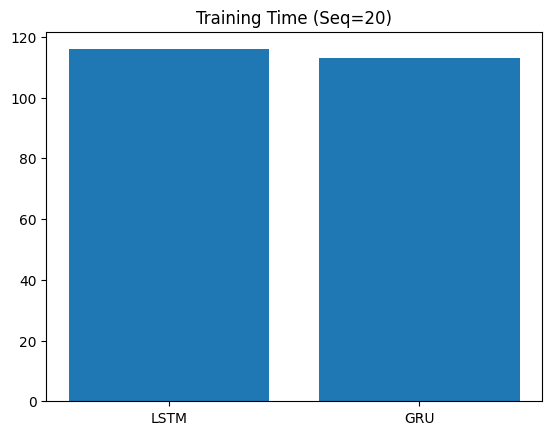

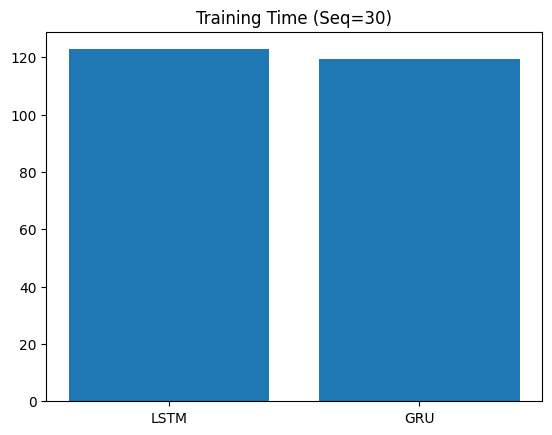

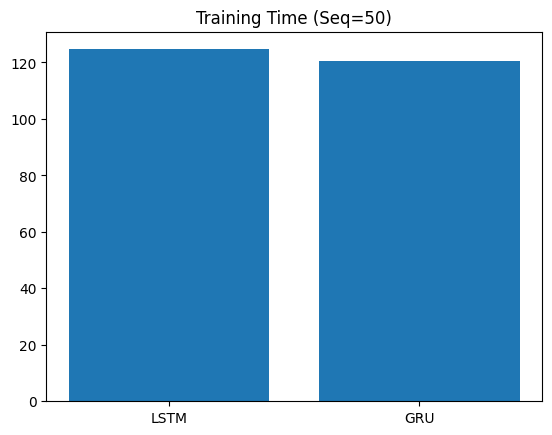

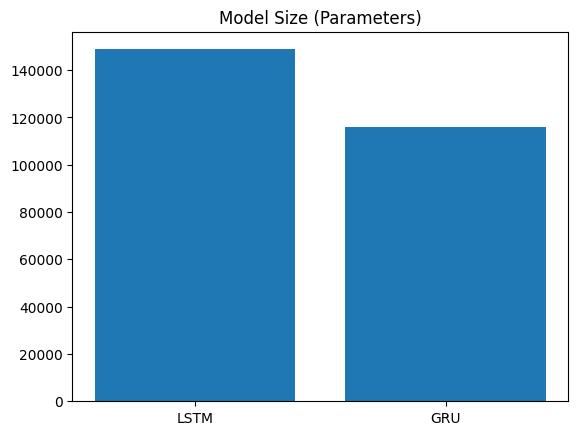

In [25]:
for (model_type, seq_len), res in results.items():
    plt.figure()
    plt.plot(res["train_loss"], label="Train Loss")
    plt.plot(res["val_loss"], label="Val Loss")
    plt.plot(res["val_acc"], label="Val Acc")
    plt.title(f"{model_type} | Seq={seq_len}")
    plt.legend()
    plt.show()

#Comparison ---------

#Accuracy
for seq_len in sequence_lengths:
    accs = [results[(m, seq_len)]["val_acc"][-1] for m in model_types]

    plt.figure()
    plt.bar(model_types, accs)
    plt.title(f"Final Accuracy (Seq={seq_len})")
    plt.show()

#Training Time
for seq_len in sequence_lengths:
    times = [results[(m, seq_len)]["time"] for m in model_types]

    plt.figure()
    plt.bar(model_types, times)
    plt.title(f"Training Time (Seq={seq_len})")
    plt.show()

#Model Size
sizes = [results[(m, 20)]["params"] for m in model_types]

plt.figure()
plt.bar(model_types, sizes)
plt.title("Model Size (Parameters)")
plt.show()

HyperParameter Adjustments:

In [26]:
configs = [
    {"hidden": 64, "layers": 1},
    {"hidden": 128, "layers": 1},
    {"hidden": 128, "layers": 2},
]

hyper_results = {}

for config in configs:
    print(f"\nConfig: {config}")

    train_loader, test_loader, vocab_size, _, _ = build_loaders(text, 20)

    model = CharModel("LSTM", vocab_size,
                      hidden_size=config["hidden"],
                      num_layers=config["layers"])

    params = sum(p.numel() for p in model.parameters())

    _, _, val_accs, train_time = train_model(model, train_loader, test_loader)

    hyper_results[str(config)] = {
        "accuracy": val_accs[-1],
        "time": train_time,
        "params": params
    }


Config: {'hidden': 64, 'layers': 1}
Epoch 1: Train Loss=1.8777, Val Acc=0.4853
Epoch 2: Train Loss=1.6869, Val Acc=0.5020
Epoch 3: Train Loss=1.6408, Val Acc=0.5121
Epoch 4: Train Loss=1.6167, Val Acc=0.5168
Epoch 5: Train Loss=1.6016, Val Acc=0.5178

Config: {'hidden': 128, 'layers': 1}
Epoch 1: Train Loss=1.7492, Val Acc=0.5187
Epoch 2: Train Loss=1.5597, Val Acc=0.5326
Epoch 3: Train Loss=1.5140, Val Acc=0.5407
Epoch 4: Train Loss=1.4904, Val Acc=0.5460
Epoch 5: Train Loss=1.4758, Val Acc=0.5446

Config: {'hidden': 128, 'layers': 2}
Epoch 1: Train Loss=1.7264, Val Acc=0.5283
Epoch 2: Train Loss=1.5131, Val Acc=0.5452
Epoch 3: Train Loss=1.4644, Val Acc=0.5501
Epoch 4: Train Loss=1.4402, Val Acc=0.5549
Epoch 5: Train Loss=1.4241, Val Acc=0.5569
